In [2]:
# Importamos las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Leemos el 'csv' de "propjectos_forvia"
info_forvia_processed = pd.read_csv("projectos_forvia.csv")

In [4]:
# Con .info() vemos la informacion de la cada columna
info_forvia_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Number                245 non-null    object 
 1   Active                245 non-null    object 
 2   Project Name          245 non-null    object 
 3   Project Type          245 non-null    object 
 4   Geographical scope    245 non-null    object 
 5   Project manager       245 non-null    object 
 6   State                 245 non-null    object 
 7   Percent complete      245 non-null    float64
 8   Project size          245 non-null    object 
 9   Project organization  245 non-null    object 
 10  Planned Go Live date  245 non-null    object 
 11  Project target phase  72 non-null     object 
 12  Actual Go Live date   48 non-null     object 
 13  Actual end date       0 non-null      float64
 14  BG                    245 non-null    object 
 15  Closed                1

In [5]:
# Con .head() nos lanza por completo el csv para ver bien todas la columnas y filas
info_forvia_processed.head()

,Number,Active,Project Name,Project Type,Geographical scope,Project manager,State,Percent complete,Project size,Project organization,...,Closed,Domain,Domain Path,Last WAR,Project Health,Project type,Recurrent activity,Planned start date,Actual start date,On-hold
0,PRJ0075198,VERDADERO,TCO - FIS - ABRERA - VW210 IP,Shopfloor JIT/TCO,ABRERA FIS,BENAVENT Pablo,Work in progress,26.47,SMALL,GIT/IT EMEA/MES & Digital Shopfloor projects,...,NaN,global,/,PRJSTAT0075304,Green,Regular,FALSO,1/2/2025 17:01,NaN,FALSO
1,PRJ0073962,VERDADERO,TCO - FCM - ALLENJOIE FHS - GEN2 New automated...,Shopfloor JIT/TCO,ALLENJOIE FCM,MAUVAIS Julien,Work in progress,52.17,LARGE,GIT/IT EMEA/MES & Digital Shopfloor projects,...,NaN,global,/,PRJSTAT0075248,Yellow,Regular,FALSO,18/01/2024 08:00:00,18/01/2024 08:00:00,VERDADERO
2,PRJ0074556,VERDADERO,TCO - FCM - ALLENJOIE FHS - Tank XL,Shopfloor JIT/TCO,ALLENJOIE FHS,THIERY Jean-Francois,Work in progress,95.85,MEDIUM,GIT/IT EMEA/MES & Digital Shopfloor projects,...,NaN,global,/,PRJSTAT0075265,Yellow,Regular,FALSO,12/8/2024 8:00,12/8/2024 8:00,FALSO
3,PRJ0075087,VERDADERO,TCO - FCM - ALLENJOIE FHS - STELLANTIS - XL694...,Shopfloor JIT/TCO,ALLENJOIE FHS,MAUVAIS Julien,Work in progress,20.90,SMALL,GIT/IT EMEA/MES & Digital Shopfloor projects,...,NaN,global,/,PRJSTAT0075325,Green,Regular,FALSO,8/1/2025 8:00,15/01/2025 09:52:03,VERDADERO
4,PRJ0075456,VERDADERO,TCO – FCM - ALMUSSAFES - FORD - C482 Welding l...,Shopfloor JIT/TCO,ALMUSSAFES FCM,BENAVENT Pablo,Work in progress,24.30,MEDIUM,GIT/IT EMEA/MES & Digital Shopfloor projects,...,NaN,global,/,PRJSTAT0075307,Green,Regular,FALSO,12/5/2025 8:00,12/5/2025 8:00,FALSO


### Con isnull y sum vemos todos los datos nulos que hay dentro de cada columna

In [6]:
info_forvia_processed.isnull().sum()

Number                    1
Active                    1
Project Name              1
Project Type              1
Geographical scope        1
Project manager           1
State                     1
Percent complete          1
Project size              1
Project organization      1
Planned Go Live date      1
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        1
Closed                  245
Domain                    1
Domain Path               1
Last WAR                 14
Project Health           14
Project type              1
Recurrent activity        1
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

### Sacamos una grafica de todos los outliers que hay dentro del Data Frame

In [7]:
numeric_cols = info_forvia_processed.select_dtypes(include=np.number).columns

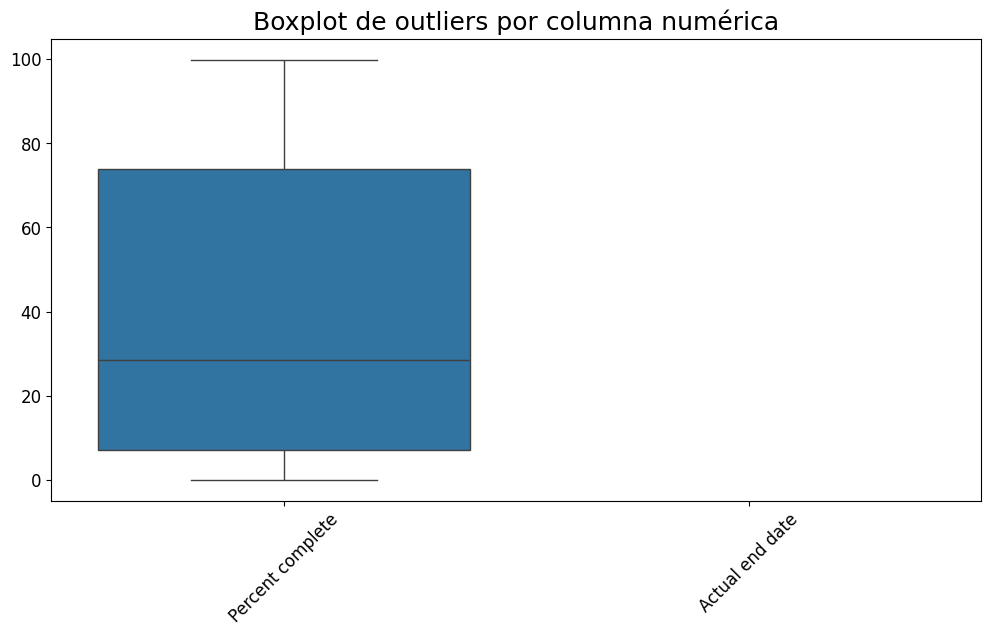

In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=info_forvia_processed[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot de outliers por columna numérica")
plt.show()

## Empezamos a remover todos los valores nulos, o sustitydendolos

In [9]:
info_forvia_processed[["Number", "Active", "Project Name"]] = info_forvia_processed[["Number", "Active", "Project Name"]].fillna("NO DEFINE")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              1
Geographical scope        1
Project manager           1
State                     1
Percent complete          1
Project size              1
Project organization      1
Planned Go Live date      1
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        1
Closed                  245
Domain                    1
Domain Path               1
Last WAR                 14
Project Health           14
Project type              1
Recurrent activity        1
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

In [10]:
info_forvia_processed[["Number", "Active", "Project Name"]] = info_forvia_processed[["Number", "Active", "Project Name"]].fillna("NO DEFINE")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              1
Geographical scope        1
Project manager           1
State                     1
Percent complete          1
Project size              1
Project organization      1
Planned Go Live date      1
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        1
Closed                  245
Domain                    1
Domain Path               1
Last WAR                 14
Project Health           14
Project type              1
Recurrent activity        1
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

### En este caso en la columna de "Percent complete" al ser porcentajes, damomos como valor 0, ya que en si no hay una forma de sacarles por asi decirlo una "media", mas que nada porque habria un desfase de los valores

In [11]:
info_forvia_processed[["Percent complete"]] = info_forvia_processed[["Percent complete"]].fillna("0")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              1
Geographical scope        1
Project manager           1
State                     1
Percent complete          0
Project size              1
Project organization      1
Planned Go Live date      1
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        1
Closed                  245
Domain                    1
Domain Path               1
Last WAR                 14
Project Health           14
Project type              1
Recurrent activity        1
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

In [12]:
info_forvia_processed[["Project size", "Project organization", "Planned Go Live date"]] = info_forvia_processed[["Project size", "Project organization", "Planned Go Live date"]].fillna("NO DEFINE")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              1
Geographical scope        1
Project manager           1
State                     1
Percent complete          0
Project size              0
Project organization      0
Planned Go Live date      0
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        1
Closed                  245
Domain                    1
Domain Path               1
Last WAR                 14
Project Health           14
Project type              1
Recurrent activity        1
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

### En esta parte de la columna "Domain" solo habia un valor nulo, y en toda la columna estaba la leyende de "Global", por lo que se decidio solo agregarle otro mas.

In [13]:
info_forvia_processed[["Domain"]] = info_forvia_processed[["Domain"]].fillna("Global")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              1
Geographical scope        1
Project manager           1
State                     1
Percent complete          0
Project size              0
Project organization      0
Planned Go Live date      0
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        1
Closed                  245
Domain                    0
Domain Path               1
Last WAR                 14
Project Health           14
Project type              1
Recurrent activity        1
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

In [14]:
info_forvia_processed[["BG"]] = info_forvia_processed[["BG"]].fillna("NO DEFINE")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              1
Geographical scope        1
Project manager           1
State                     1
Percent complete          0
Project size              0
Project organization      0
Planned Go Live date      0
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        0
Closed                  245
Domain                    0
Domain Path               1
Last WAR                 14
Project Health           14
Project type              1
Recurrent activity        1
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

### En esta parte lo mismo que en "Domain" ya que solo habia una celda vacia y con los mismos datos

In [15]:
info_forvia_processed[["Domain Path"]] = info_forvia_processed[["Domain Path"]].fillna("/")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              1
Geographical scope        1
Project manager           1
State                     1
Percent complete          0
Project size              0
Project organization      0
Planned Go Live date      0
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        0
Closed                  245
Domain                    0
Domain Path               0
Last WAR                 14
Project Health           14
Project type              1
Recurrent activity        1
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

### De la misma manera en esta parte

In [16]:
info_forvia_processed[["Project type"]] = info_forvia_processed[["Project type"]].fillna("REGULAR")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              1
Geographical scope        1
Project manager           1
State                     1
Percent complete          0
Project size              0
Project organization      0
Planned Go Live date      0
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        0
Closed                  245
Domain                    0
Domain Path               0
Last WAR                 14
Project Health           14
Project type              0
Recurrent activity        1
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

### De igual manera en esta parte

In [17]:
info_forvia_processed[["Recurrent activity"]] = info_forvia_processed[["Recurrent activity"]].fillna("FALSO")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              1
Geographical scope        1
Project manager           1
State                     1
Percent complete          0
Project size              0
Project organization      0
Planned Go Live date      0
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        0
Closed                  245
Domain                    0
Domain Path               0
Last WAR                 14
Project Health           14
Project type              0
Recurrent activity        0
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

In [18]:
info_forvia_processed[["On-hold"]] = info_forvia_processed[["On-hold"]].fillna("NO DEFINE")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              1
Geographical scope        1
Project manager           1
State                     1
Percent complete          0
Project size              0
Project organization      0
Planned Go Live date      0
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        0
Closed                  245
Domain                    0
Domain Path               0
Last WAR                 14
Project Health           14
Project type              0
Recurrent activity        0
Planned start date        0
Actual start date        19
On-hold                   0
dtype: int64

## En esta parte borramos dos columnas, la primera "Actual end date" ya que esta vacia, y en "Closed" solo habia un dato

In [19]:
info_forvia_processed=info_forvia_processed.drop(['Actual end date', 'Closed'],axis=1)
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              1
Geographical scope        1
Project manager           1
State                     1
Percent complete          0
Project size              0
Project organization      0
Planned Go Live date      0
Project target phase    174
Actual Go Live date     198
BG                        0
Domain                    0
Domain Path               0
Last WAR                 14
Project Health           14
Project type              0
Recurrent activity        0
Planned start date        0
Actual start date        19
On-hold                   0
dtype: int64

In [20]:
info_forvia_processed[["Project target phase", "Actual Go Live date", "Last WAR", "Project Health", "Actual start date"]] = info_forvia_processed[["Project target phase", "Actual Go Live date", "Last WAR", "Project Health", "Actual start date"]].fillna("NO DEFINE")
info_forvia_processed.isnull().sum()

Number                  0
Active                  0
Project Name            0
Project Type            1
Geographical scope      1
Project manager         1
State                   1
Percent complete        0
Project size            0
Project organization    0
Planned Go Live date    0
Project target phase    0
Actual Go Live date     0
BG                      0
Domain                  0
Domain Path             0
Last WAR                0
Project Health          0
Project type            0
Recurrent activity      0
Planned start date      0
Actual start date       0
On-hold                 0
dtype: int64

## Realizamos un analisis univariado de las variables categoricas, mostrando tablas de frecuencias y graficas de barras para cada una.

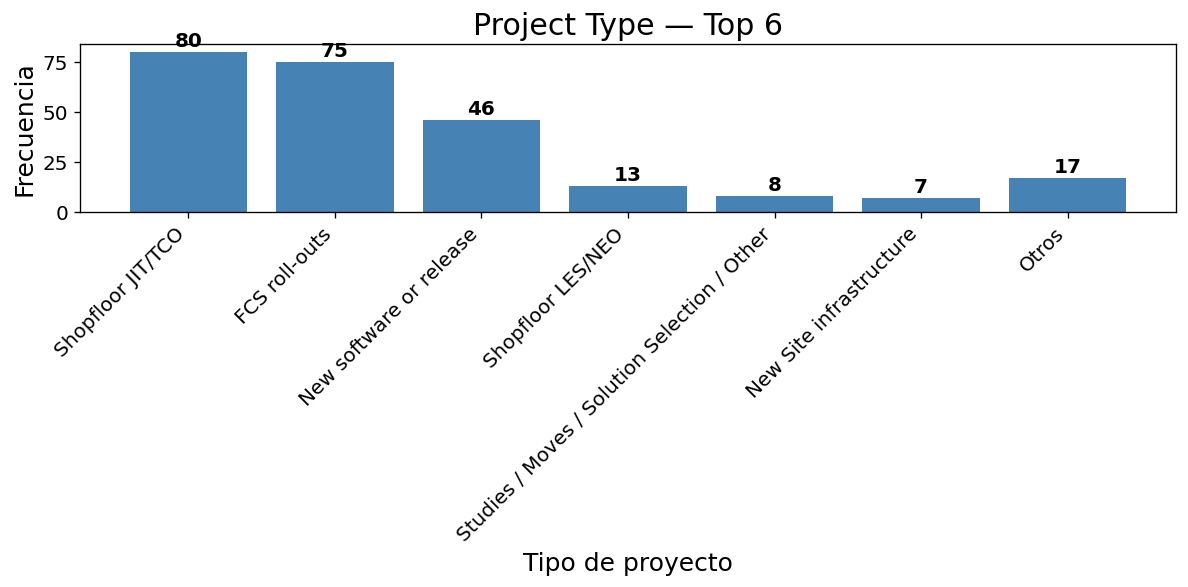

In [37]:
import matplotlib.pyplot as plt

# Top 6 + agrupar el resto como "Otros"
Filtro = info_forvia_processed["Project Type"].astype(str).value_counts()
top6 = Filtro.head(6)
otros = Filtro.iloc[6:].sum()
if otros > 0:
    top6.loc["Otros"] = otros

# Gráfico de barras
plt.figure(figsize=(10,5))
bars = plt.bar(top6.index, top6.values, color="steelblue")

plt.title("Project Type — Top 6", fontsize=18)
plt.xlabel("Tipo de proyecto", fontsize=15)
plt.ylabel("Frecuencia", fontsize=15)
plt.xticks(rotation=45, ha="right")

# Etiquetas arriba de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval),
             ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


In [38]:
# Frecuencias
Filtro = info_forvia_processed["Geographical scope"].astype(str).value_counts()

# Top 6 + agrupar el resto como "Otros"
top6 = Filtro.head(6)
otros = Filtro.iloc[6:].sum()
if otros > 0:
    top6.loc["Otros"] = otros

# Ajustar índice
Filtro_index = top6.reset_index()
Filtro_index.columns = ["Geographical scope", "count"]
Filtro_index = Filtro_index.set_index("Geographical scope")
Filtro_index


,count
Geographical scope,
WORLD WIDE,20
BRAZIL,9
PUEBLA HQ,7
BRAGANCA,6
PARIS TECH CENTER,5
LIPPSTADT 2 HQH & FES R&D,5
Otros,194


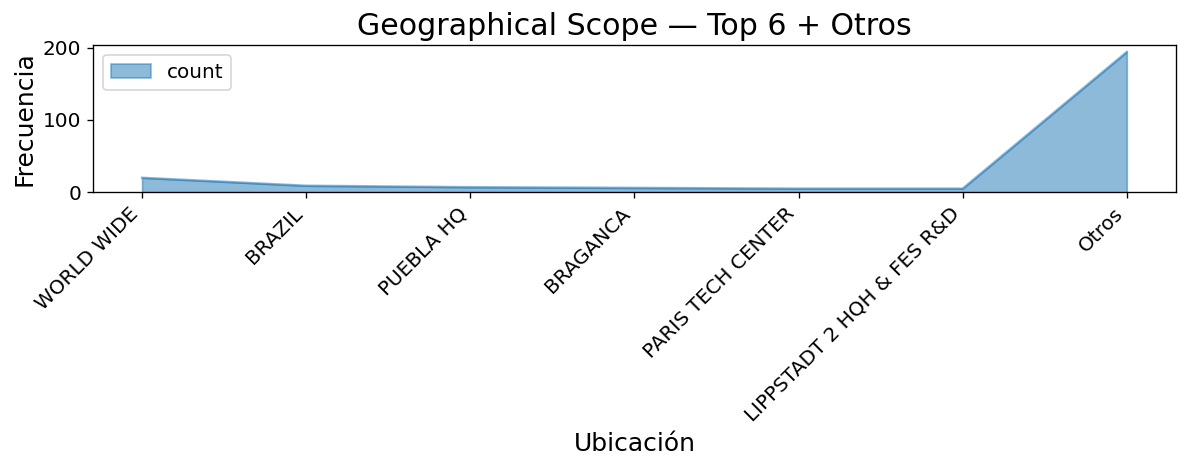

In [39]:
# Gráfico de área
Filtro_index.plot(kind='area', figsize=(10,4), alpha=0.5)

plt.title("Geographical Scope — Top 6 + Otros", fontsize=18)
plt.xlabel("Ubicación", fontsize=15)
plt.ylabel("Frecuencia", fontsize=15)

plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


In [40]:
# Frecuencias de Project manager
Filtro = info_forvia_processed["Project manager"].astype(str).value_counts()

# Top 6 + agrupar el resto como "Otros"
top6 = Filtro.head(6)
otros = Filtro.iloc[6:].sum()
if otros > 0:
    top6.loc["Otros"] = otros

# Ajustar índice
Filtro_index = top6.reset_index()
Filtro_index.columns = ["Project manager", "count"]
Filtro_index = Filtro_index.set_index("Project manager")
Filtro_index


,count
Project manager,
SOUZA Alexandre,15
BENAVENT Pablo,12
SVARICEK Dan,9
LOUBET Diana,9
MALTER Karsten,7
LOURENCO Douglas,6
Otros,188


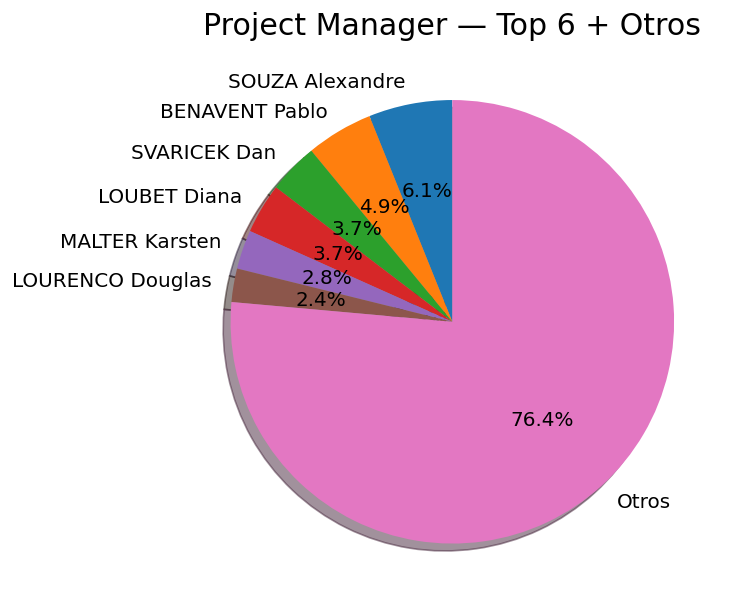

In [41]:
# Gráfico de pastel
Filtro_index["count"].plot(
    kind='pie',
    figsize=(8,6),
    shadow=True,
    autopct="%0.1f%%",
    startangle=90,
    textprops={"fontsize":12}
)

plt.title("Project Manager — Top 6 + Otros", fontsize=18)
plt.ylabel("")  # Quitar texto extra del eje Y
plt.show()


In [ ]:
# Frecuencias de State
Filtro = info_forvia_processed["State"].astype(str).value_counts().reset_index()
Filtro.columns = ["State", "count"]

# Ajustar índice
Filtro_index = Filtro.set_index("State")
Filtro_index


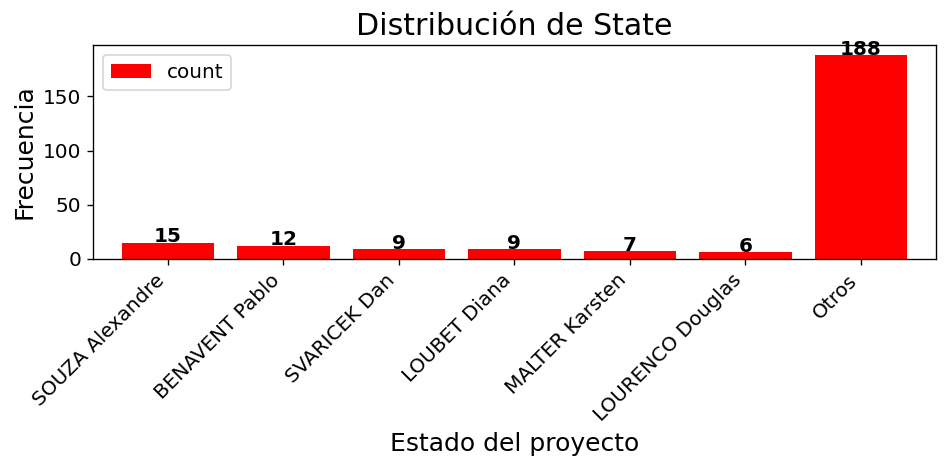

In [42]:
# Gráfico de barras para State
Filtro_index.plot(kind='bar', width=0.8, figsize=(8,4), color="red")

plt.title("Distribución de State", fontsize=18)
plt.xlabel("Estado del proyecto", fontsize=15)
plt.ylabel("Frecuencia", fontsize=15)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(fontsize=12)

# Mostrar valores encima de cada barra
for i, v in enumerate(Filtro_index["count"]):
    plt.text(i, v + 0.5, str(int(v)), ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


In [43]:
# Frecuencias de Project Size
Filtro = info_forvia_processed["Project size"].astype(str).value_counts().reset_index()
Filtro.columns = ["Project size", "count"]

# Ajustar índice
Filtro_index = Filtro.set_index("Project size")
Filtro_index


,count
Project size,
MEDIUM,103
LARGE,81
SMALL,61
NO DEFINE,1


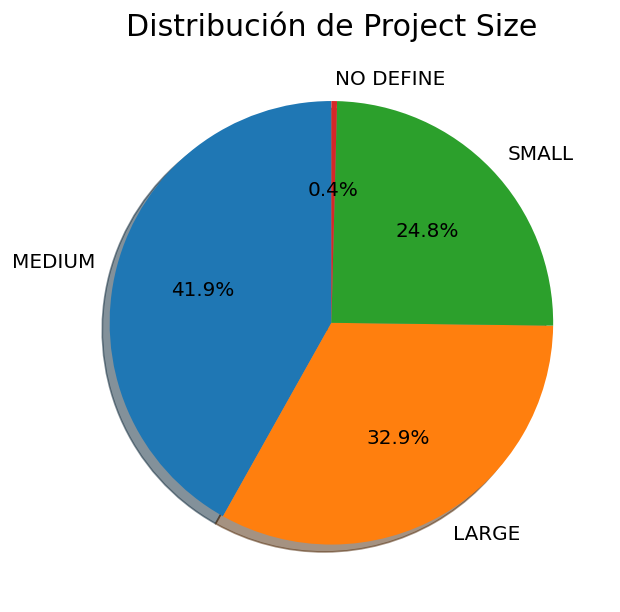

In [44]:
# Gráfico de pastel para Project Size
Filtro_index["count"].plot(
    kind='pie',
    figsize=(8,6),
    shadow=True,
    autopct="%0.1f%%",
    startangle=90,
    textprops={"fontsize":12}
)

plt.title("Distribución de Project Size", fontsize=18)
plt.ylabel("")  # quitar texto extra
plt.show()


In [45]:
# Frecuencias de Project organization
Filtro = info_forvia_processed["Project organization"].astype(str).value_counts()

# Top 6 + agrupar el resto
top6 = Filtro.head(6)
otros = Filtro.iloc[6:].sum()
if otros > 0:
    top6.loc["Otros"] = otros

# Ajustar índice
Filtro_index = top6.reset_index()
Filtro_index.columns = ["Project organization", "count"]
Filtro_index = Filtro_index.set_index("Project organization")
Filtro_index


,count
Project organization,
GIT/IT EMEA/MES & Digital Shopfloor projects,61
GIT/IT EMEA/Applications rollouts & Level 2 Support,42
GIS/ITOP SAO./IT OP SAO shared/ITOP SAO FCS & BPA.,15
GIS/ITOP ASIA/IT OP Asia Shared/ITOP ASIA MES & Digital Transformation,14
GIT/IT NAO/MES Applications & DT/Mexico MES,13
GIT/Applications,10
Otros,91


C:\Users\Usuario\AppData\Local\Temp\ipykernel_2044\1625974950.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


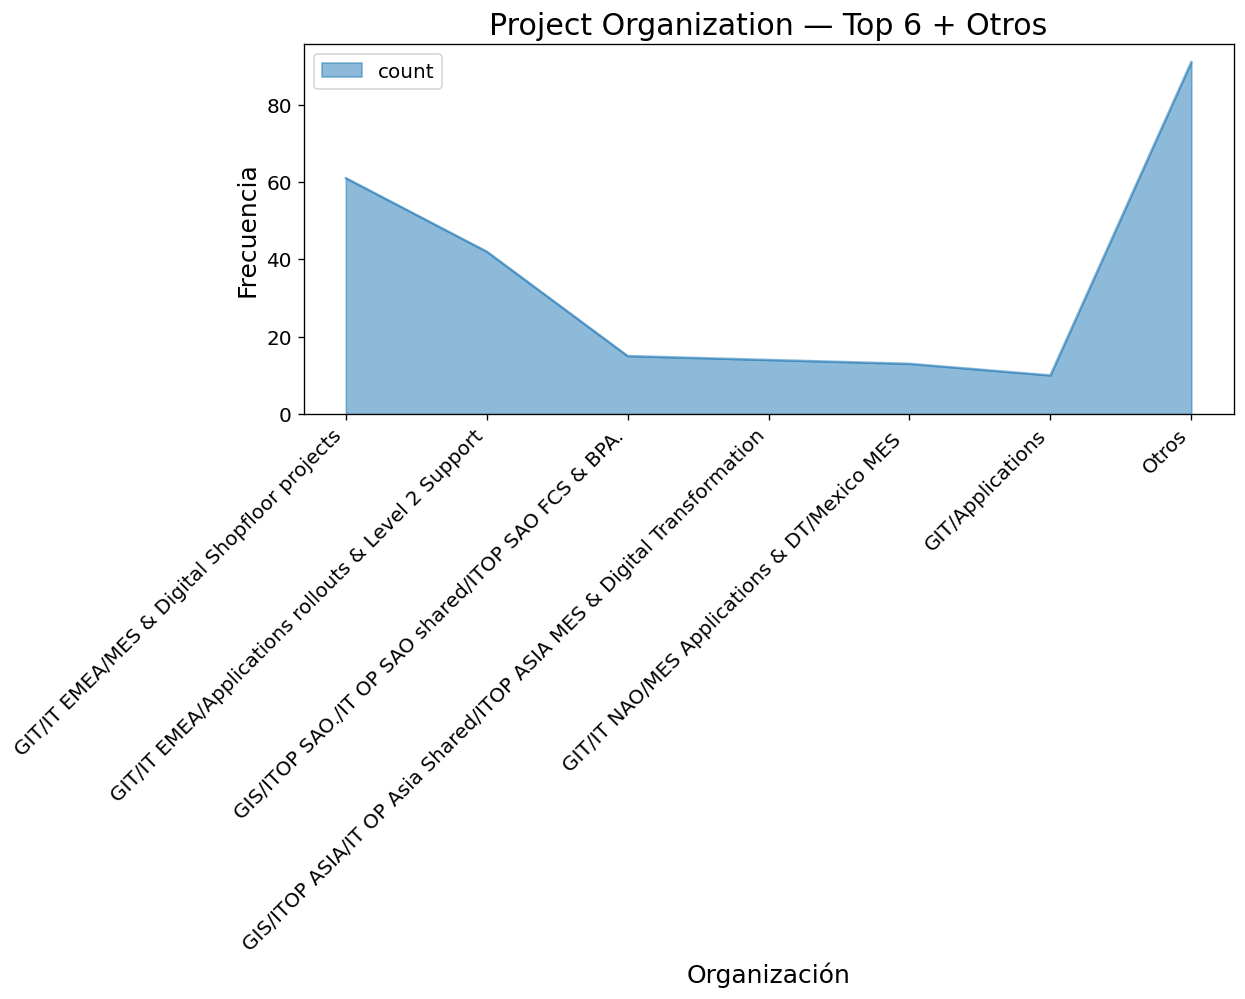

In [46]:
# Gráfico de área
Filtro_index.plot(kind='area', figsize=(10,4), alpha=0.5)

plt.title("Project Organization — Top 6 + Otros", fontsize=18)
plt.xlabel("Organización", fontsize=15)
plt.ylabel("Frecuencia", fontsize=15)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


In [47]:
# Frecuencias de BG
Filtro = info_forvia_processed["BG"].astype(str).value_counts().reset_index()
Filtro.columns = ["BG", "count"]

# Ajustar índice
Filtro_index = Filtro.set_index("BG")
Filtro_index


,count
BG,
FIS,69
FCM,57
FAS,45
GROUP,40
FCE,8
FLG,8
FES,6
HQH,6
FLV,5


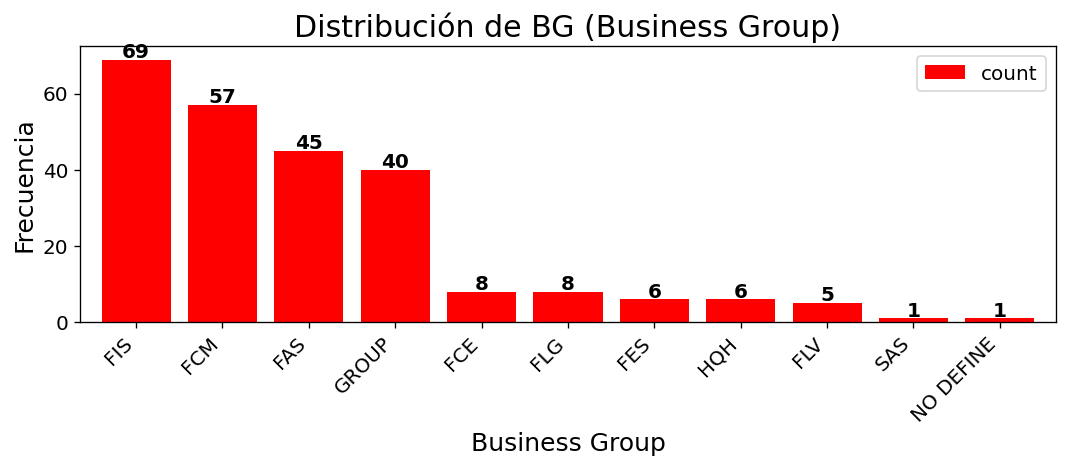

In [48]:
# Gráfico de barras para BG
ax = Filtro_index.plot(kind='bar', width=0.8, figsize=(9,4), color="red")

plt.title("Distribución de BG (Business Group)", fontsize=18)
plt.xlabel("Business Group", fontsize=15)
plt.ylabel("Frecuencia", fontsize=15)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(fontsize=12)

# Etiquetas encima de las barras
for i, v in enumerate(Filtro_index["count"]):
    plt.text(i, v + 0.5, str(int(v)), ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


In [49]:
# Frecuencias de Project Health
Filtro = info_forvia_processed["Project Health"].astype(str).value_counts().reset_index()
Filtro.columns = ["Project Health", "count"]

# Ajustar índice
Filtro_index = Filtro.set_index("Project Health")
Filtro_index


,count
Project Health,
Green,183
Yellow,49
NO DEFINE,14


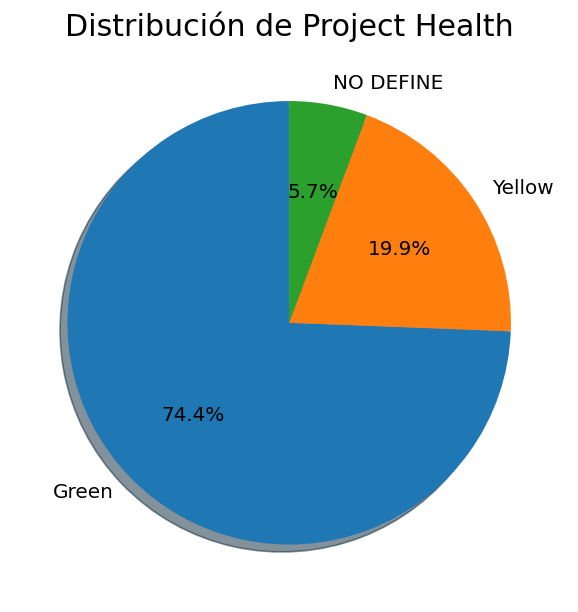

In [50]:
# Gráfico de pastel para Project Health
Filtro_index["count"].plot(
    kind='pie',
    figsize=(8,6),
    shadow=True,
    autopct="%0.1f%%",
    startangle=90,
    textprops={"fontsize":12}
)

plt.title("Distribución de Project Health", fontsize=18)
plt.ylabel("")  # Quitar texto extra
plt.show()


In [51]:
# Frecuencias de On-hold
Filtro = info_forvia_processed["On-hold"].astype(str).value_counts().reset_index()
Filtro.columns = ["On-hold", "count"]

# Ajustar índice
Filtro_index = Filtro.set_index("On-hold")
Filtro_index


,count
On-hold,
FALSO,195
VERDADERO,50
NO DEFINE,1


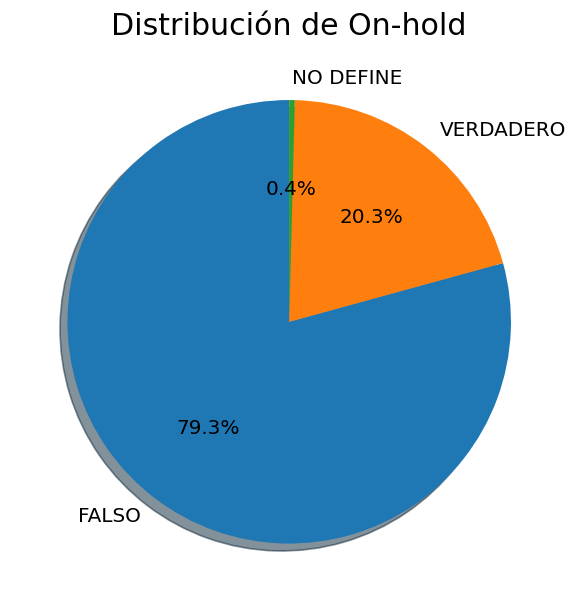

In [52]:
# Gráfico de pastel para On-hold
Filtro_index["count"].plot(
    kind='pie',
    figsize=(8,6),
    shadow=True,
    autopct="%0.1f%%",
    startangle=90,
    textprops={"fontsize":12}
)

plt.title("Distribución de On-hold", fontsize=18)
plt.ylabel("")  # Quitar texto extra
plt.show()


## Convertimos la columna a numarica para evitar errores

In [22]:
info_forvia_processed["Percent complete"] = pd.to_numeric(info_forvia_processed["Percent complete"], errors="coerce")

## Calculamos el número de bins con la regla de sturges

In [23]:
n = info_forvia_processed["Percent complete"].dropna().shape[0]
bins = int(1 + 3.322 * np.log10(n))

## Creamos las categorias

In [24]:
info_forvia_processed["Percent_complete_cat"] = pd.cut(
    info_forvia_processed["Percent complete"],
    bins=bins,
    labels=[f"Grupo {i+1}" for i in range(bins)]
)

## Creamos una tabla de frecuencias

In [25]:
freq_table = info_forvia_processed["Percent_complete_cat"].value_counts().sort_index()
display(freq_table.to_frame())

,count
Percent_complete_cat,
Grupo 1,78
Grupo 2,37
Grupo 3,30
Grupo 4,16
Grupo 5,13
Grupo 6,11
Grupo 7,14
Grupo 8,47


## Graficamos con el metodo de barras

In [53]:
# Ver cómo están definidos los grupos (intervalos en %)
info_forvia_processed["Percent_complete_cat"].cat.categories


Index(['Grupo 1', 'Grupo 2', 'Grupo 3', 'Grupo 4', 'Grupo 5', 'Grupo 6',
       'Grupo 7', 'Grupo 8'],
      dtype='object')

In [55]:
# Tabla con algunos campos clave por grupo
tabla_grupos = info_forvia_processed.groupby("Percent_complete_cat").apply(
    lambda x: x[["Project Name", "Project manager", "State", "Percent complete"]].head(5) # muestra 5 ejemplos por grupo
)

tabla_grupos


C:\Users\Usuario\AppData\Local\Temp\ipykernel_2044\2923170928.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_grupos = info_forvia_processed.groupby("Percent_complete_cat").apply(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_2044\2923170928.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla_grupos = info_forvia_processed.groupby("Percent_complete_cat").apply(


Project Name  \
Percent_complete_cat                                                          
Grupo 1              9                            E-supply retrofit project   
                     10   FCS - FCM - US Holdings LLC - Imp New US Legal...   
                     11   ITOP - GIT - NAO - Server Room Remediation Pro...   
                     17        FOR_Automatized entrance software for trucks   
                     23   FCS Customer Flow – FCM Bragança – Customer VW...   
Grupo 2              3    TCO - FCM - ALLENJOIE FHS - STELLANTIS - XL694...   
                     4    TCO – FCM - ALMUSSAFES - FORD - C482 Welding l...   
                     5                              Deployment  NEO for ANH   
                     12        FCS - GROUP - WW - IT Consignment Deployment   
                     33                    Atualização FCS x Notas Técnicas   
Grupo 3              0                        TCO - FIS - ABRERA - VW210 IP   
                     14   FCS  Customer Flow - FCM Augsburg -  DMND00275...   
                     25         TCO - FCM - BRAGANCA - RSA - SM12L Mufflers   
                     28                    Correção de cálculo de retenções   
                     43                    Changzhou FIS 2679 FCS migration   
Grupo 4              15   FCS Customer flow - FCM - Augsburg - Jaguar La...   
                     16   FCS Customer Flow – FIS BSO - Opel Automobile ...   
                     46       NAO - FIS - MCT - MATERIACT Phase 2 - Overall   
                     66                     EREPLENISHMENT - FIS - HLOHOVEC   
                     74                   Jinhua FAS creation Infra project   
Grupo 5              1    TCO - FCM - ALLENJOIE FHS - GEN2 New automated...   
                     13   TCO - FCM - AUGSBURG - VW - KASSEL takeover (4...   
                     19            FCS -FIS - Blue Springs - EWM Deployment   
                     20   TCO - FCM - BRAGANCA - VW - E12020B Canning fr...   
                     35               TOLSYS : Software to Manage stack-ups   
Grupo 6              71              Roll out FCS to FIS Tochigi plant 2574   
                     99                         EWM WH Efficiency – Lozorno   
                     103                          NEO/PREACTOR - FIS - MERU   
                     126                  TCO - FIS - PALMELA - VW386 IP FG   
                     136                        Connector ProMISE - PLM4FCE   
Grupo 7              44   Chengdu plant Preactor/ NEO deployment(1924 & ...   
                     68     TCO - FIS - HLOHOVEC- STELLANTIS - CC2x/OV24 IP   
                     69   Preactor/NEO  implementation request for FCM K...   
                     78      TCO - FCM - KOCAELI - RENAULT - SM12L  E11599C   
                     105  FOR_SAP - FLG - HAM - L SMT Plant (PL 9) - Rol...   
Grupo 8              2                  TCO - FCM - ALLENJOIE FHS - Tank XL   
                     6                         Reaplicação de request Dzyon   
                     7                  EWM - FIS - ARGES - INBOUND PROCESS   
                     8    FCS Plant Maintenance & Mobility - FIS Arges -...   
                     18                          OCR CONTROL - FCM - BAVANS   

                                        Project manager             State  \
Percent_complete_cat                                                        
Grupo 1              9                        LEI Oscar  Work in progress   
                     10                       TRAN Khoi  Work in progress   
                     11                     HELMLE Kyle  Work in progress   
                     17                     BAKO Martin  Work in progress   
                     23                 LUCAS Margarida  Work in progress   
Grupo 2              3                   MAUVAIS Julien  Work in progress   
                     4                   BENAVENT Pablo  Work in progress   
                     5                          LON

In [56]:
# Resumen con rango y frecuencia
resumen_grupos = pd.DataFrame({
    "Rango (%)": info_forvia_processed["Percent_complete_cat"].cat.categories.astype(str),
    "Frecuencia": info_forvia_processed["Percent_complete_cat"].value_counts().sort_index().values
})
resumen_grupos


,Rango (%),Frecuencia
0,Grupo 1,78
1,Grupo 2,37
2,Grupo 3,30
3,Grupo 4,16
4,Grupo 5,13
5,Grupo 6,11
6,Grupo 7,14
7,Grupo 8,47


In [58]:
for grupo, subset in info_forvia_processed.groupby("Percent_complete_cat"):
    print(f"\n=== {grupo} ===")
    print(subset[["Project Name", "Project manager", "Percent complete"]].head(3))  # primeros 3 de cada grupo



=== Grupo 1 ===
                                         Project Name Project manager  \
9                           E-supply retrofit project       LEI Oscar   
10  FCS - FCM - US Holdings LLC - Imp New US Legal...       TRAN Khoi   
11  ITOP - GIT - NAO - Server Room Remediation Pro...     HELMLE Kyle   

    Percent complete  
9               9.98  
10              0.00  
11              0.00  

=== Grupo 2 ===
                                        Project Name Project manager  \
3  TCO - FCM - ALLENJOIE FHS - STELLANTIS - XL694...  MAUVAIS Julien   
4  TCO – FCM - ALMUSSAFES - FORD - C482 Welding l...  BENAVENT Pablo   
5                            Deployment  NEO for ANH         LONG Pu   

   Percent complete  
3             20.90  
4             24.30  
5             13.18  

=== Grupo 3 ===
                                         Project Name Project manager  \
0                       TCO - FIS - ABRERA - VW210 IP  BENAVENT Pablo   
14  FCS  Customer Flow - FCM Augsburg -  

C:\Users\Usuario\AppData\Local\Temp\ipykernel_2044\2787207225.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grupo, subset in info_forvia_processed.groupby("Percent_complete_cat"):


C:\Users\Usuario\AppData\Local\Temp\ipykernel_2044\1129542192.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_multiline, rotation=0, ha="center", fontsize=10)


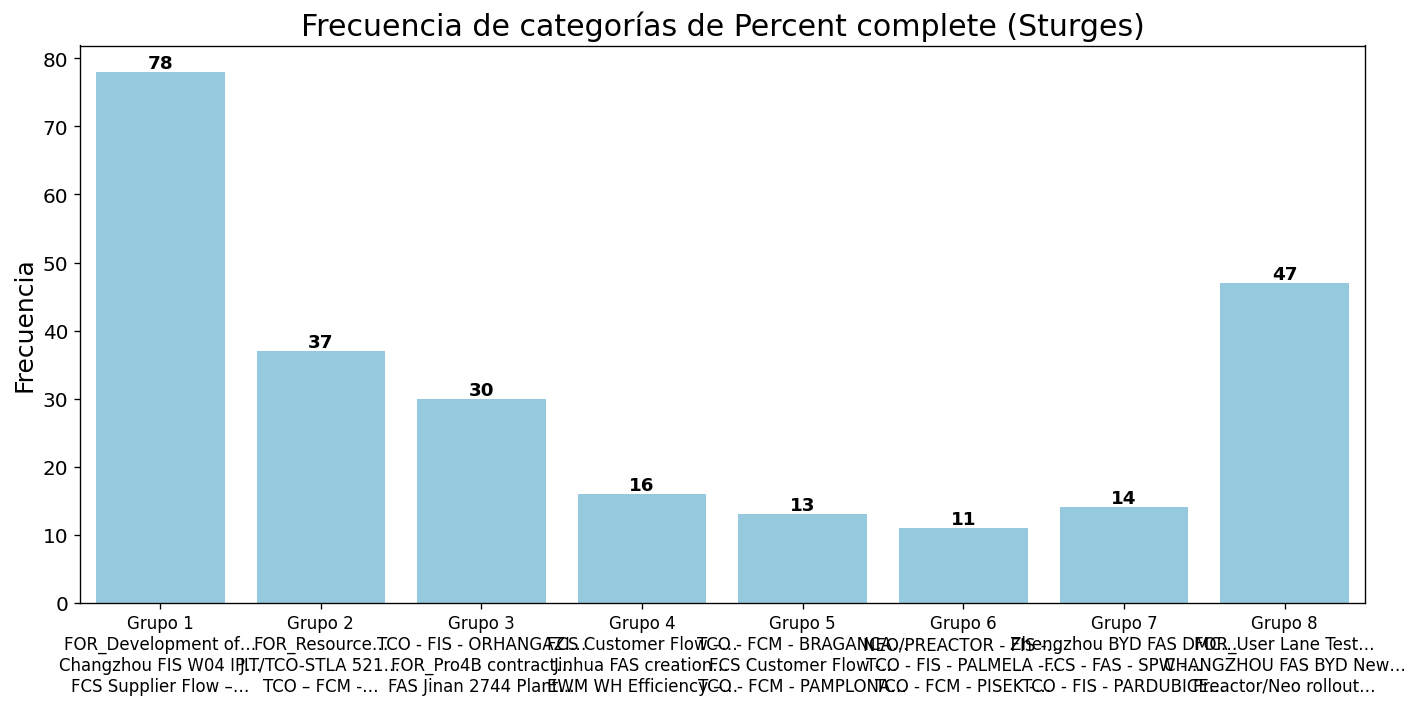

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import shorten

# --- Orden de grupos ---
freq_table = info_forvia_processed["Percent_complete_cat"].value_counts().sort_index()

# --- Función: top 3 proyectos (por mayor avance) ---
def top3_names(df_group, name_col="Project Name", score_col="Percent complete"):
    g = df_group.sort_values(by=score_col, ascending=False)  # mayor avance primero
    names = g[name_col].fillna("N/A").astype(str).head(3).tolist()
    # recortar nombres largos
    names = [shorten(n, width=22, placeholder="…") for n in names]
    # unir en multilinea con saltos
    return "\n".join(names)

# Crear etiquetas (Grupo + 3 proyectos)
labels_multiline = []
for grp in freq_table.index:
    subset = info_forvia_processed[info_forvia_processed["Percent_complete_cat"] == grp]
    bullets = top3_names(subset)
    labels_multiline.append(f"{grp}\n{bullets}")

# --- Gráfico de barras ---
plt.figure(figsize=(12,6))
ax = sns.countplot(
    x="Percent_complete_cat",
    data=info_forvia_processed,
    order=freq_table.index,
    color="skyblue"
)

plt.title("Frecuencia de categorías de Percent complete (Sturges)", fontsize=18)
plt.xlabel("")  
plt.ylabel("Frecuencia", fontsize=15)

# Etiquetas con conteo encima
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=11, fontweight="bold")

# Reemplazar ticks por los labels con 3 proyectos
ax.set_xticklabels(labels_multiline, rotation=0, ha="center", fontsize=10)

# Dejar espacio extra abajo para los nombres multilínea
plt.gcf().subplots_adjust(bottom=0.35)

plt.tight_layout()
plt.show()
